<a href="https://colab.research.google.com/github/Ullas2534/Projects/blob/main/Instagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/train (1).csv")


In [ ]:
df.head()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
0,1,0.27,0,0.0,0,53,0,0,32,1000,955,0
1,1,0.00,2,0.0,0,44,0,0,286,2740,533,0
2,1,0.10,2,0.0,0,0,0,1,13,159,98,0
3,1,0.00,1,0.0,0,82,0,0,679,414,651,0
4,1,0.00,2,0.0,0,0,0,1,6,151,126,0


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB


In [ ]:
df.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


In [ ]:
# Check for missing values
print(df.isnull().sum())

# Fill or drop missing values as necessary
df.fillna(0, inplace=True)  # Example: Filling missing values with 0


profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64


In [ ]:
# Convert binary features
binary_columns = ['profile pic', 'name==username', 'external URL', 'private']
for col in binary_columns:
    df[col] = df[col].apply(lambda x: 1 if x else 0)

# Example of creating a new feature
df['followers_to_follows_ratio'] = df['#followers'] / (df['#follows'] + 1)  # Avoid division by zero


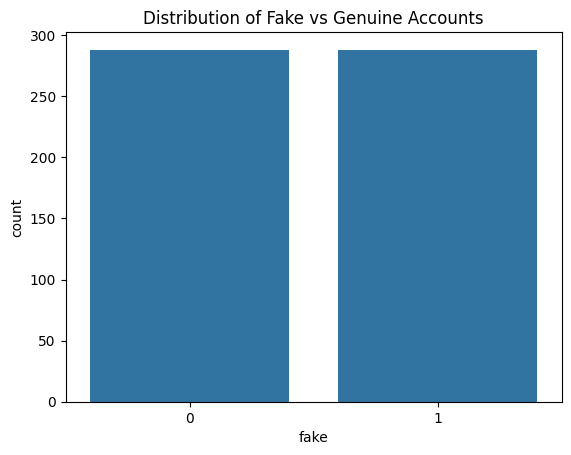

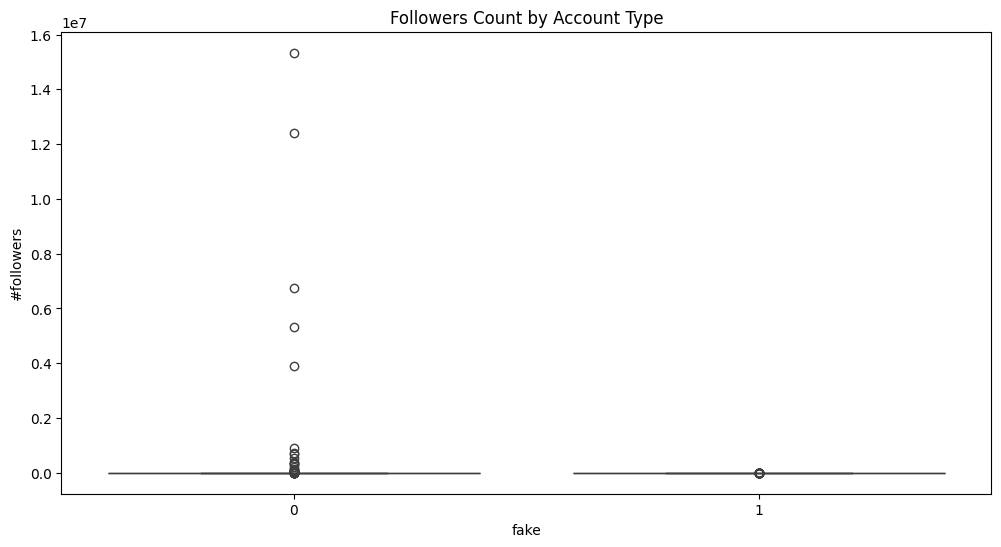

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of the target variable
sns.countplot(x='fake', data=df)
plt.title('Distribution of Fake vs Genuine Accounts')
plt.show()

# Box plots for numerical features
plt.figure(figsize=(12, 6))
sns.boxplot(x='fake', y='#followers', data=df)
plt.title('Followers Count by Account Type')
plt.show()


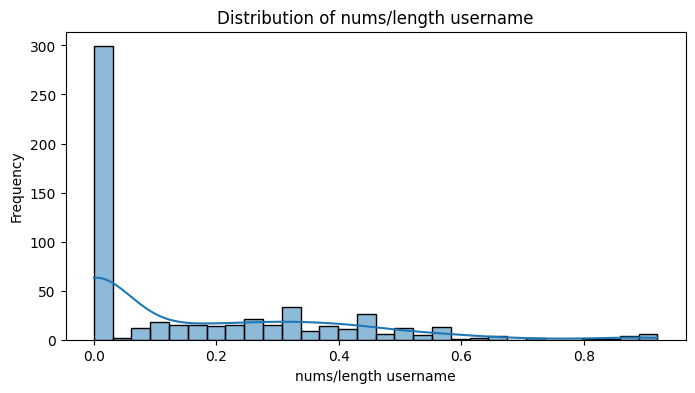

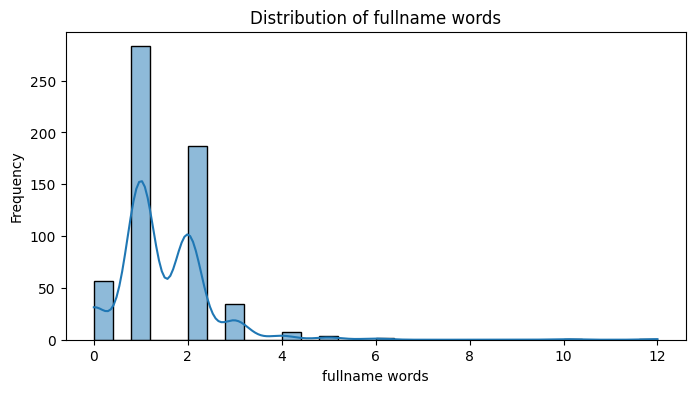

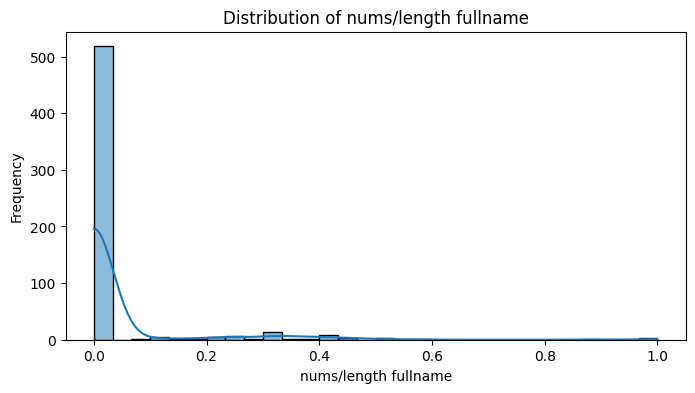

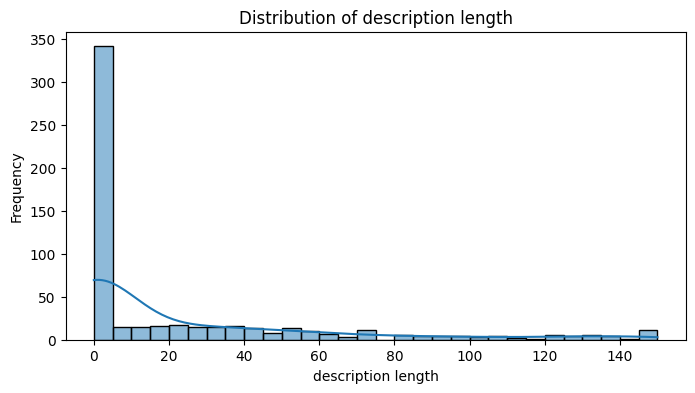

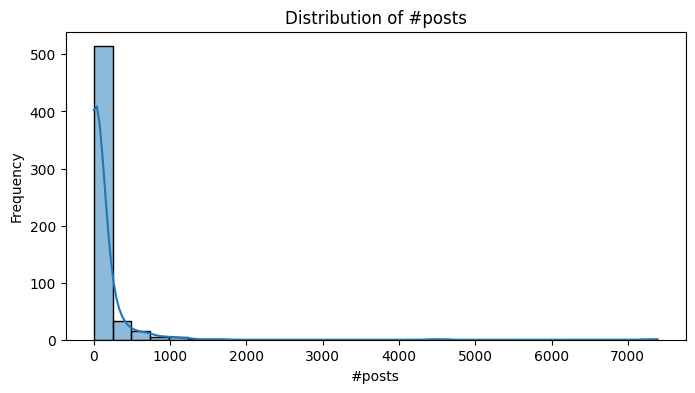

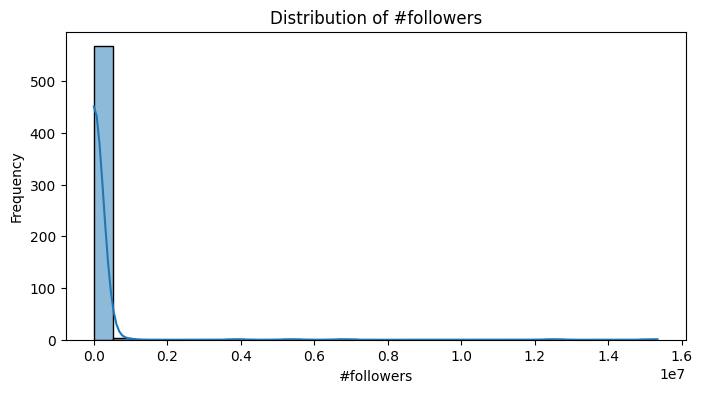

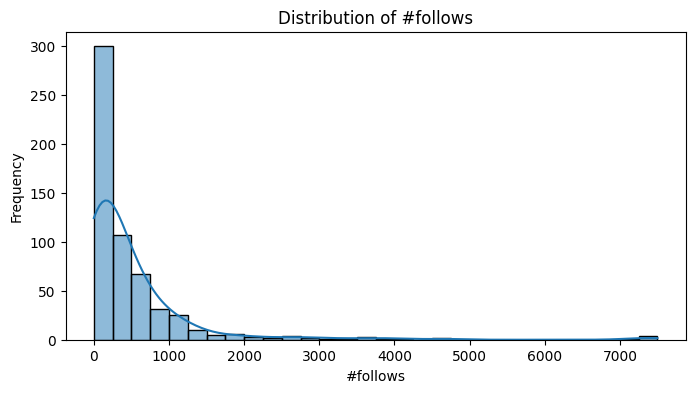

In [ ]:
# Histograms for numerical features
numerical_features = ['nums/length username', 'fullname words', 'nums/length fullname',
                      'description length', '#posts', '#followers', '#follows']

for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()


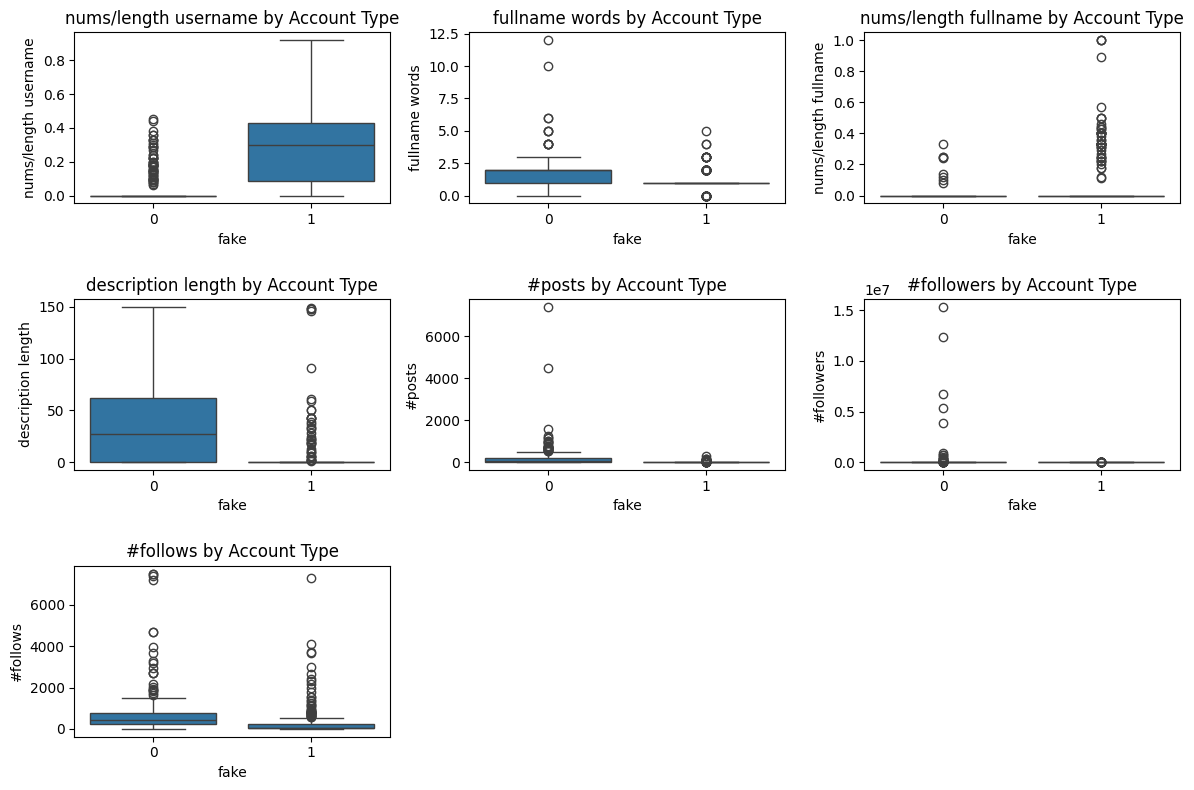

In [ ]:
# Box plots for numerical features by 'fake' status
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='fake', y=feature, data=df)
    plt.title(f'{feature} by Account Type')
plt.tight_layout()
plt.show()


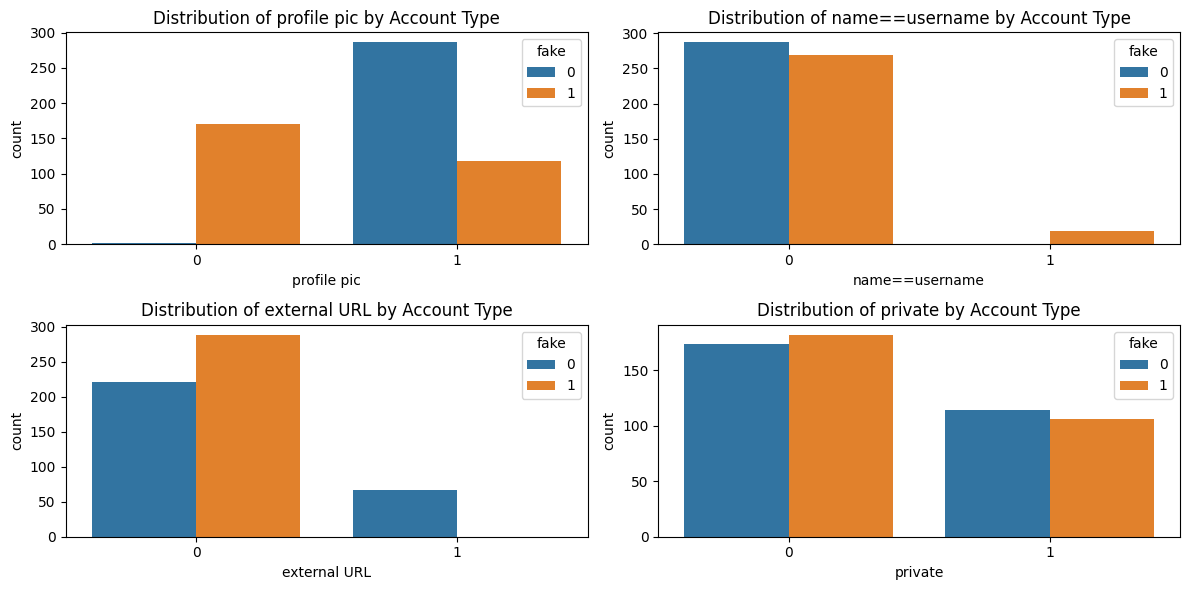

In [ ]:
# Count plots for binary features
binary_features = ['profile pic', 'name==username', 'external URL', 'private']

plt.figure(figsize=(12, 6))
for i, feature in enumerate(binary_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=feature, hue='fake', data=df)
    plt.title(f'Distribution of {feature} by Account Type')
plt.tight_layout()
plt.show()



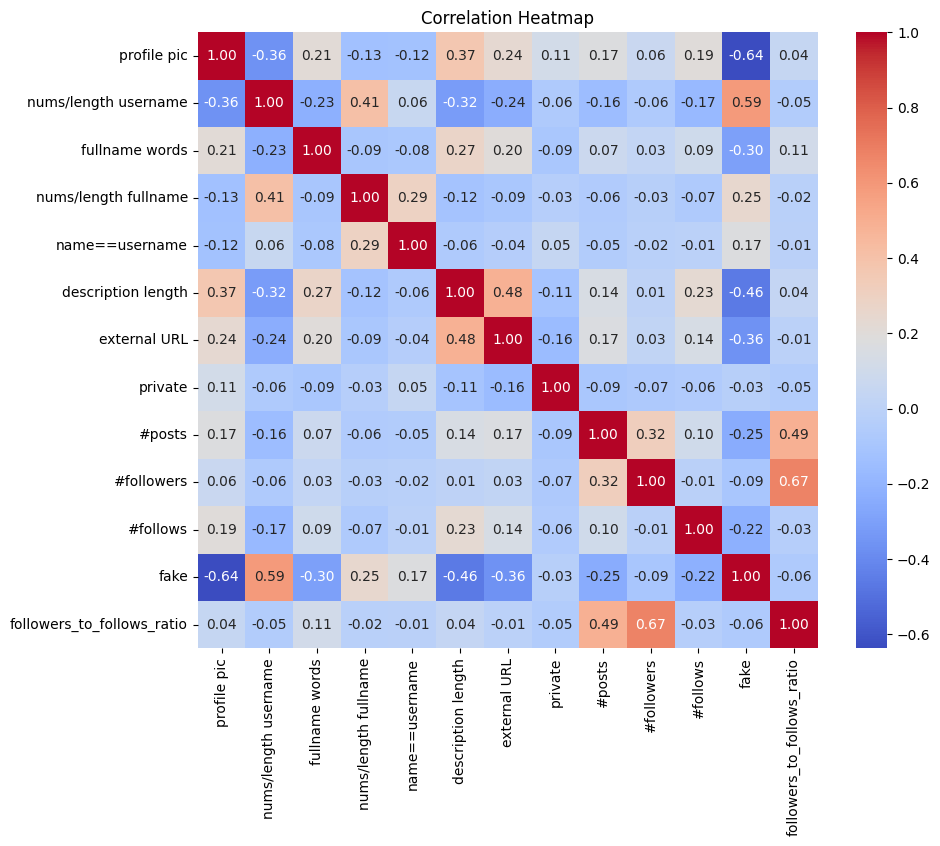

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


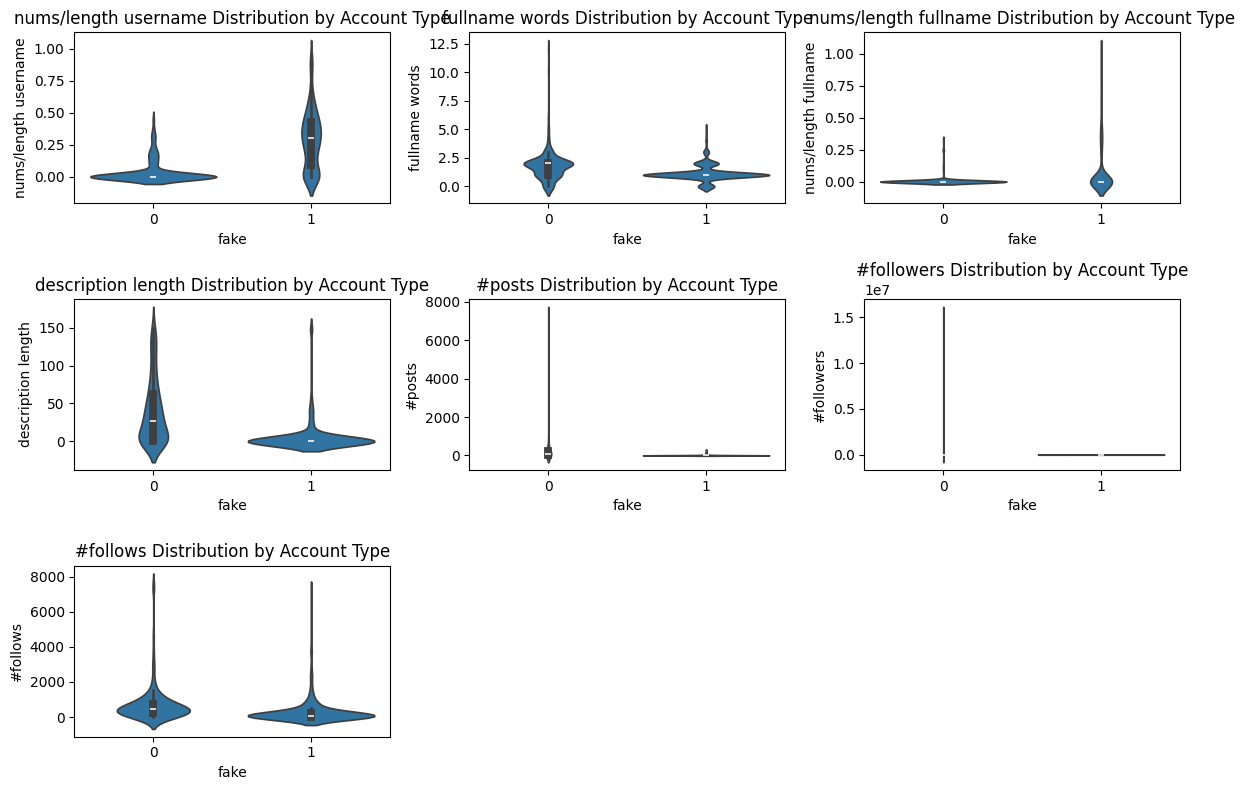

In [ ]:
# Violin plots for numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.violinplot(x='fake', y=feature, data=df)
    plt.title(f'{feature} Distribution by Account Type')
plt.tight_layout()
plt.show()


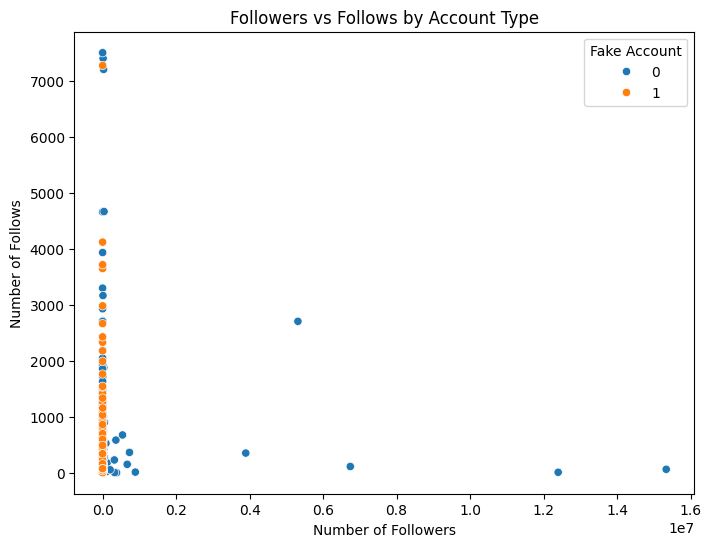

In [ ]:
# Scatter plot example
plt.figure(figsize=(8, 6))
sns.scatterplot(x='#followers', y='#follows', hue='fake', data=df)
plt.title('Followers vs Follows by Account Type')
plt.xlabel('Number of Followers')
plt.ylabel('Number of Follows')
plt.legend(title='Fake Account')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features and target variable
X = df.drop('fake', axis=1)  # Features
y = df['fake']  # Target variable

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))




              precision    recall  f1-score   support

           0       0.89      0.92      0.91        63
           1       0.90      0.87      0.88        53

    accuracy                           0.90       116
   macro avg       0.90      0.89      0.90       116
weighted avg       0.90      0.90      0.90       116

